In [1]:
import os
import shutil
from functools import partial

import matplotlib.pyplot as plt
import numpy as np
import cupy as cp
import pandas as pd

from spd.sdfb_simulator import SPD_Simulator
from superfv import HydroSolver, HydroSolverOutput, TimeIntegrator, ics

base_directory = "/scratch/gpfs/jp7427/FVvsSD/sinus/"

def reduce_CFL(N: int, p: int, initial_CFL: float = 0.8, qmax: int = 3) -> float:
    if p > qmax:
        return initial_CFL * ((1 / N) ** ((p - qmax) / (qmax + 1)))
    else:
        return initial_CFL

In [2]:
def run_superfv_sim(name, p, N, **kwargs):
    path = base_directory + f"FV_{name}_{N=}_{p=}"

    try:
        out = HydroSolverOutput(path)
        print(f"Loaded output from '{path}'")
        return out
    except Exception as e:
        print(f"Failed to load output from '{path}' with: {e}")
        pass

    if os.path.exists(path):
        print(f"Removing bad output at '{path}'")
        shutil.rmtree(path)

    sim = HydroSolver(
        ic=partial(ics.sinus, vx=2.0, vy=1.0),
        rho_min=1e-10,
        P_min=1e-10,
        nx=N,
        ny=N,
        p=p,
        CFL=reduce_CFL(N, p),
        cupy=True,
        output_path=path,
        **kwargs,
    )
    sim.run(1.0, time_integrator=TimeIntegrator.RK4)
    return sim


def run_spd_sim(name, p, NDOF, **kwargs):
    path = base_directory + f"SD_{name}_{NDOF=}_{p=}"

    def sine_wave(xy: np.ndarray, case: int, vx=1, vy=1, P=1):
        x = xy[0]
        y = xy[1]
        if case == 0:
            # density
            return 1.5 + 0.5 * np.sin(2 * np.pi * (x + y))
        elif case == 1:
            # vx
            return vx * np.ones(x.shape)
        elif case == 2:
            # vy
            return vy * np.ones(x.shape)
        elif case == 4:
            # Pressure
            return P * np.ones(x.shape)
        else:
            return np.zeros(x.shape)

    Nelements = NDOF // (p + 1)

    sim = SPD_Simulator(
        p=p,
        N=(Nelements, Nelements),
        init_fct=partial(sine_wave, vx=2.0, vy=1.0),
        cfl_coeff=reduce_CFL(NDOF, p, 0.4),
        use_cupy=True,
        time_integrator="rk4",
        scheme="SD",
        FB=False,
        riemann_solver_sd="hllc",  # MUSCL fallback flux
        folder=path,
        **kwargs,
    )

    try:
        sim.load_output()
        print(f"Loaded output from '{path}'")
        return sim
    except Exception as e:
        print(f"Failed to load output from '{path}' with: {e}")
        pass

    sim.perform_time_evolution(1.0)
    sim.output()
    return sim

def get_superfv_error_map(name, p, N, **kwargs):
    sim = run_superfv_sim(name, p, N, **kwargs)
    x, y, _ = sim.mesh.faces
    return cp.asnumpy(x), cp.asnumpy(y), sim.snapshot_history[-1].u - sim.snapshot_history[0].u

def get_spd_error_map(name, p, NDOF, **kwargs):
    sim1 = run_spd_sim(name, p, NDOF, **kwargs)

    def sine_wave(xy: np.ndarray, case: int, vx=1, vy=1, P=1):
        x = xy[0]
        y = xy[1]
        if case == 0:
            # density
            return 1.5 + 0.5 * np.sin(2 * np.pi * (x + y))
        elif case == 1:
            # vx
            return vx * np.ones(x.shape)
        elif case == 2:
            # vy
            return vy * np.ones(x.shape)
        elif case == 4:
            # Pressure
            return P * np.ones(x.shape)
        else:
            return np.zeros(x.shape)

    Nelements = NDOF // (p + 1)

    sim0 = SPD_Simulator(
        p=p,
        N=(Nelements, Nelements),
        init_fct=partial(sine_wave, vx=2.0, vy=1.0),
        cfl_coeff=reduce_CFL(NDOF, p, 0.4),
        use_cupy=True,
        time_integrator="rk4",
        scheme="SD",
        FB=False,
        riemann_solver_sd="hllc",  # MUSCL fallback flux
        **kwargs,
    )

    U0_sp = sim0.dm.asnumpy(sim0.dm.U_sp)
    U1_sp = sim1.dm.asnumpy(sim1.dm.U_sp)
    
    E = U1_sp - U0_sp
    E = sim1.transpose_to_fv(E)
    
    x_sp = sim1.dm.asnumpy(sim1.dm.X_sp).reshape(-1)
    y_sp = sim1.dm.asnumpy(sim1.dm.Y_sp).reshape(-1)

    return x_sp, y_sp, E

    # x_sd1 = sim1.regular_faces()[0]
    # y_sd1 = sim1.regular_faces()[1]
    # z_sd1 = sim1.transpose_to_fv(sim1.regular_mesh(sim1.dm.W_cv))
    # z_sd0 = sim0.transpose_to_fv(sim0.regular_mesh(sim0.dm.W_cv))
    # return x_sd1, y_sd1, z_sd1 - z_sd0

In [3]:
data = []
for NDOF in [16, 32, 64, 128, 256]:
    for p in [3, 7]:
        _, _, fv_err = get_superfv_error_map("", p, NDOF)
        linf_err = np.max(np.abs(fv_err[0, ...])).item()
        data.append(dict(scheme="FV", ndof=NDOF, p=p, err=linf_err))
                    
        _, _, sd_err = get_spd_error_map("", p, NDOF)
        linf_err = np.max(np.abs(sd_err[0, ...])).item()
        data.append(dict(scheme="SD", ndof=NDOF, p=p, err=linf_err))
df = pd.DataFrame(data)

Loaded output from '/scratch/gpfs/jp7427/FVvsSD/sinus/FV__N=16_p=3'
-> Loaded snapshot at t=1.0 from /scratch/gpfs/jp7427/FVvsSD/sinus/FV__N=16_p=3/output_000001.pkl.
-> Loaded snapshot at t=0.0 from /scratch/gpfs/jp7427/FVvsSD/sinus/FV__N=16_p=3/output_000000.pkl.
Loaded output from '/scratch/gpfs/jp7427/FVvsSD/sinus/SD__NDOF=16_p=3'
Loaded output from '/scratch/gpfs/jp7427/FVvsSD/sinus/FV__N=16_p=7'
-> Loaded snapshot at t=1.0 from /scratch/gpfs/jp7427/FVvsSD/sinus/FV__N=16_p=7/output_000001.pkl.
-> Loaded snapshot at t=0.0 from /scratch/gpfs/jp7427/FVvsSD/sinus/FV__N=16_p=7/output_000000.pkl.
Loaded output from '/scratch/gpfs/jp7427/FVvsSD/sinus/SD__NDOF=16_p=7'
Loaded output from '/scratch/gpfs/jp7427/FVvsSD/sinus/FV__N=32_p=3'
-> Loaded snapshot at t=1.0 from /scratch/gpfs/jp7427/FVvsSD/sinus/FV__N=32_p=3/output_000001.pkl.
-> Loaded snapshot at t=0.0 from /scratch/gpfs/jp7427/FVvsSD/sinus/FV__N=32_p=3/output_000000.pkl.
Loaded output from '/scratch/gpfs/jp7427/FVvsSD/sinus/SD__ND

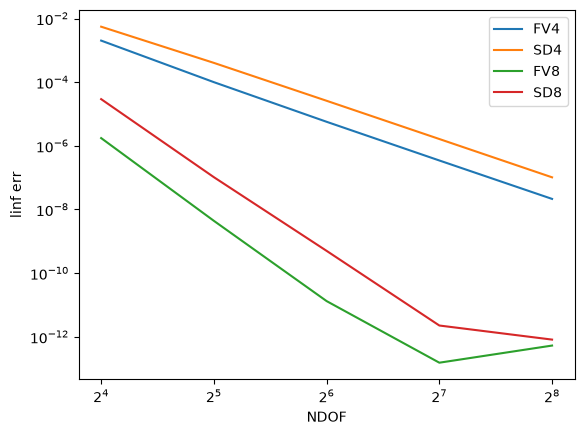

In [4]:
def plot(ax, df, *args, **kwargs):
    ax.plot(df.ndof, df.err, *args, **kwargs)

fig, ax = plt.subplots()
ax.set_xscale("log", base=2)
ax.set_yscale("log")

plot(ax, df[(df.scheme == "FV") & (df.p == 3)], label="FV4")
plot(ax, df[(df.scheme == "SD") & (df.p == 3)], label="SD4")

plot(ax, df[(df.scheme == "FV") & (df.p == 7)], label="FV8")
plot(ax, df[(df.scheme == "SD") & (df.p == 7)], label="SD8")

ax.legend()
ax.set_xlabel("NDOF")
ax.set_ylabel("linf err")

fig.savefig("sine_wave_convergence.pdf")

Loaded output from '/scratch/gpfs/jp7427/FVvsSD/sinus/FV__N=128_p=3'
-> Loaded snapshot at t=1.0 from /scratch/gpfs/jp7427/FVvsSD/sinus/FV__N=128_p=3/output_000001.pkl.
-> Loaded snapshot at t=0.0 from /scratch/gpfs/jp7427/FVvsSD/sinus/FV__N=128_p=3/output_000000.pkl.
Loaded output from '/scratch/gpfs/jp7427/FVvsSD/sinus/FV__N=128_p=7'
-> Loaded snapshot at t=1.0 from /scratch/gpfs/jp7427/FVvsSD/sinus/FV__N=128_p=7/output_000001.pkl.
-> Loaded snapshot at t=0.0 from /scratch/gpfs/jp7427/FVvsSD/sinus/FV__N=128_p=7/output_000000.pkl.
Loaded output from '/scratch/gpfs/jp7427/FVvsSD/sinus/SD__NDOF=128_p=3'
Loaded output from '/scratch/gpfs/jp7427/FVvsSD/sinus/SD__NDOF=128_p=7'


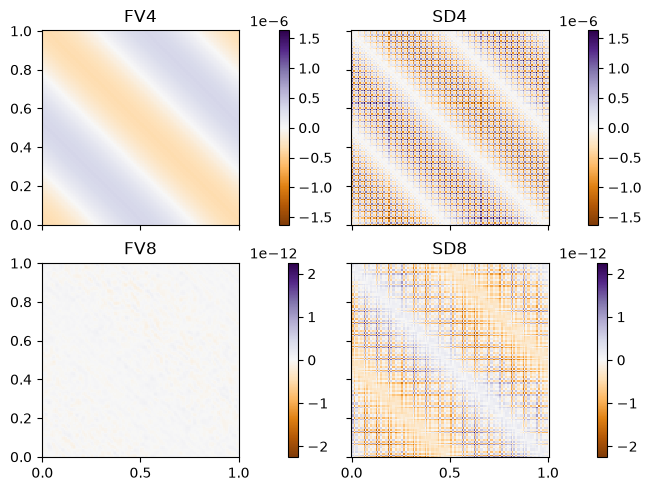

In [5]:
fig, axs = plt.subplots(2, 2, sharex=True, sharey=True, constrained_layout=True)

axs[0, 0].set_title("FV4")
x, y, err = get_superfv_error_map("", 3, 128)
m0 = axs[0, 0].pcolormesh(x, y, err[0, :, :, 0], cmap="PuOr")
fig.colorbar(m0, ax=axs[0, 0], pad=0)

axs[1, 0].set_title("FV8")
x, y, err = get_superfv_error_map("", 7, 128)
m1 = axs[1, 0].pcolormesh(x, y, err[0, :, :, 0], cmap="PuOr")
fig.colorbar(m1, ax=axs[1, 0], pad=0)

axs[0, 1].set_title("SD4")
x, y, err = get_spd_error_map("", 3, 128)
m2 = axs[0, 1].pcolormesh(x, y, err[0, :, :], cmap="PuOr")
fig.colorbar(m2, ax=axs[0, 1], pad=0)

axs[1, 1].set_title("SD8")
x, y, err = get_spd_error_map("", 7, 128)
m3 = axs[1, 1].pcolormesh(x, y, err[0, :, :], cmap="PuOr")
fig.colorbar(m3, ax=axs[1, 1], pad=0)

vmin = min(m.get_array().min() for m in [m0, m2])
vmax = max(m.get_array().max() for m in [m0, m2])
vmax = max(abs(vmin), abs(vmax))
m0.set_clim(-vmax, vmax)
m2.set_clim(-vmax, vmax)

vmin = min(m.get_array().min() for m in [m1, m3])
vmax = max(m.get_array().max() for m in [m1, m3])
vmax = max(abs(vmin), abs(vmax))
m1.set_clim(-vmax, vmax)
m3.set_clim(-vmax, vmax)